In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = np.loadtxt(
    "data.csv",
    delimiter=",",
    skiprows=1
)

# Features and labels
X = data[:, :8]
y = data[:, 8]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# If target is binary (0/1), convert predictions to class labels
y_pred_class = (y_pred >= 0.5).astype(int)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Accuracy for classification-like output
accuracy = np.mean(y_pred_class == y_test) * 100
error_percent = np.mean(y_pred_class != y_test) * 100

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

print("MSE:", mse)
print("R² Score:", r2)

print("Accuracy:", accuracy)
print("Error %:", error_percent)

Coefficients: [-0.0328754   0.16226778  0.08402116 -0.16833094  0.05499371 -0.18427789
 -0.10453814  0.15695045]
Intercept: 0.5305966865566025
MSE: 0.12939503420089007
R² Score: 0.4759501114863953
Accuracy: 85.47008547008546
Error %: 14.529914529914532


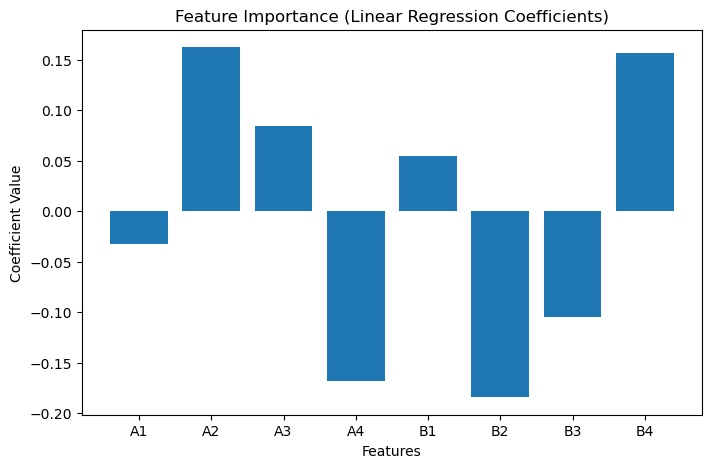

In [4]:
feature_names = [
    "A1", "A2", "A3", "A4",
    "B1", "B2", "B3", "B4"
]

plt.figure(figsize=(8, 5))
plt.bar(feature_names, model.coef_)

plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Feature Importance (Linear Regression Coefficients)")

plt.show()

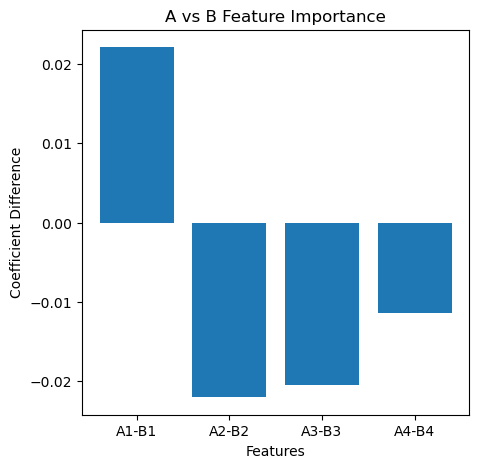

In [2]:
import matplotlib.pyplot as plt

feature_names = [
    "A1-B1",
    "A2-B2",
    "A3-B3",
    "A4-B4"
]

# Difference in paired coefficients
coef_diff = model.coef_[0:4] + model.coef_[4:8]

plt.figure(figsize=(5, 5))
plt.bar(feature_names, coef_diff)

plt.xlabel("Features")
plt.ylabel("Coefficient Difference")
plt.title("A vs B Feature Importance")

plt.show()

Here we can clearly see, the value are not zero and showing a bias to a person for each feature.
If we have just used differences of features for comparision(wiA+wiB=0), this wouldn't be the case.
Thus if we use differences in place of raw features, this information is lost!!
